<a href="https://colab.research.google.com/github/OscarBuzz2006/SNN-NWN-COMPARISON/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST

# Setup Edamame code base from GitHub < .zip

In [1]:
import sys
import os
#from pathlib import Path
#root_path = str(Path(os.path.dirname(os.path.realpath(__file__))).parent)
#sys.path.append(root_path)
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pickle
from tqdm import tqdm



In [ ]:
!unzip '/content/edamame-fork-YH.zip' -d edamame-fork


Archive:  /content/edamame-fork-YH.zip
bd331f32fe4ec4d478ac920e8001fb426b13e480
   creating: edamame-fork/edamame-fork-YH/
  inflating: edamame-fork/edamame-fork-YH/.DS_Store  
  inflating: edamame-fork/edamame-fork-YH/.gitattributes  
  inflating: edamame-fork/edamame-fork-YH/.gitignore  
  inflating: edamame-fork/edamame-fork-YH/LICENSE  
  inflating: edamame-fork/edamame-fork-YH/README.md  
   creating: edamame-fork/edamame-fork-YH/cluster/
  inflating: edamame-fork/edamame-fork-YH/cluster/TEcalc.csh  
  inflating: edamame-fork/edamame-fork-YH/cluster/forecast_multi.csh  
  inflating: edamame-fork/edamame-fork-YH/cluster/runAIS.csh  
  inflating: edamame-fork/edamame-fork-YH/cluster/runAmps.csh  
  inflating: edamame-fork/edamame-fork-YH/cluster/runSimTest.csh  
  inflating: edamame-fork/edamame-fork-YH/cluster/runTE.csh  
  inflating: edamame-fork/edamame-fork-YH/cluster/runTEforecast.csh  
  inflating: edamame-fork/edamame-fork-YH/cluster/run_MNIST.csh  
   creating: edamame-fork/

In [ ]:
# Import neuromorphic network codebase: Edamame

# The path should be the directory containing the edamame package
edamame_path = 'edamame-fork/edamame-fork-YH'
# OVERWRITE path with wherever edamame-fork or edamame path is
sys.path.insert(0, edamame_path)
import edamame
from edamame import *
from edamame.core.simulate import simCore

/content/edamame-fork/edamame-fork-YH/edamame/utils/config.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [ ]:
'''Other options for network topology include'''
#Connectivity = connectivity__('100nw_261junctions.mat')
#Connectivity = connectivity__('200nw_1213junctions.mat')
'''Used 100nw first, then scaling up to 200nw'''
#Connectivity = connectivity__('500nw_9905junctions.mat')
#Connectivity = connectivity__('700nw_14533junctions.mat')

'Used 100nw first, then scaling up to 200nw'

#v_critical sweeping method (updated to sweep over multiple DC)

***We can see that network becomes saturated once T > 5s...***

In [ ]:
new_T = 10 # Simulation time (s)

'''Range used by Avalanches paper
dc_voltages = np.concatenate([
    np.arange(0.01, 0.08, 0.005),
    np.arange(0.09003, 0.09005, 0.00001),
    np.arange(0.09006, 0.09010, 0.00001),
    np.arange(0.085, 0.101, 0.0005),
    np.arange(0.101, 0.149, 0.001),
    np.arange(0.15, 0.51, 0.01),
    np.arange(0.55, 3.05, 0.05),
])'''
# Below is just the most recent ranges used. I've sampled over, [0.3, 0.5] (THIS GIVES V_CRIT)...
# Also [0.4,0.6], [0.6,0.8] and a range of other V's in [0.5,1.5] with precision of 0.01, and all the above, just to be sure
# Also sampled even finer: 0.001 around V* values the paper found [0.44, 0.45] and Zdenka found [0.53, 0.55]

dc_voltages = [0.20, 0.25, 0.26, 0.27, 0.30]
num_voltages = len(dc_voltages)
conductance_time_series = [] # List to store full conductance time series, used for simultaneous plotting of G's


print(f"Running simulations for {num_voltages} DC voltages from {dc_voltages[0]}V to {dc_voltages[-1]}V...")

for volt in dc_voltages:
  print(f"Running simulation with DC voltage amplitude: {volt:.3f}V")
  # Use the loop variable as the onAmp for the DC bias
  dc_sim = runSim(Connectivity, T = new_T, dt = 0.001, biasType = 'DC', onAmp = volt, lite_mode=False, disable_tqdm=True) # I just disabled tqdm for cleaner output during sweep

  # Get full time series
  conductance_time_series.append(dc_sim.conductance)


# Use a colormap for different colors corresponding to voltages
colors = plt.cm.viridis(np.linspace(0, 1, num_voltages))

# Plotting conductance vs. time for each voltage
plt.figure(figsize=(10, 6))


time_limit = new_T * 1000 # Assuming new_T is in ms and dt=0.001s

for i, conductance_data in enumerate(conductance_time_series):
    plot_data = conductance_data[:time_limit] if len(conductance_data) >= time_limit else conductance_data
    plt.plot(plot_data, color=colors[i], label=f'{dc_voltages[i]:.2f}V')

plt.yscale("log") # log scale
plt.title('Network Conductance over time for different DC Inputs (First {} s)'.format(new_T))
plt.xlabel('Time (ms)') # NB: adjust label if time unit is different
plt.ylabel('log of Conductance (S)')
plt.legend(title='DC Voltage')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()

final_conductances = []
for conductance_data in conductance_time_series:
  final_conductances.append(conductance_data[-1])

plt.figure(figsize=(8, 5))
plt.plot(dc_voltages, final_conductances, marker='o', linestyle='-')
plt.xlabel('Maximum Voltage (V)')
plt.ylabel('Final Conductance (S)')
plt.title('Final Network Conductance vs. Maximum Input Voltage')
plt.grid(True)
plt.show()

Running simulations for 5 DC voltages from 0.2V to 0.3V...
Running simulation with DC voltage amplitude: 0.200V


NameError: name 'Connectivity' is not defined

#Conversion to MNIST

## MNIST data loading and testing


In [ ]:
# Testing and training data
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

batch_size=100
data_path='/tmp/data/mnist'

device = torch.device("cpu")

mnist_train = datasets.MNIST(data_path, train=True, download=True)
mnist_test = datasets.MNIST(data_path, train=False, download=True)

# Convert to match the CSV format
label_train = mnist_train.targets.numpy()
train_data = mnist_train.data.numpy().reshape(60000, -1) / 255.0  # Flatten and normalize

label_test = mnist_test.targets.numpy()
test_data = mnist_test.data.numpy().reshape(10000, -1) / 255.0   # Flatten and normalize

print(len(label_train), label_train[0], train_data[0,300])
print(len(test_data), label_test[0], test_data[0,300])

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 329kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.17MB/s]


60000 5 0.0
10000 7 0.996078431372549


5


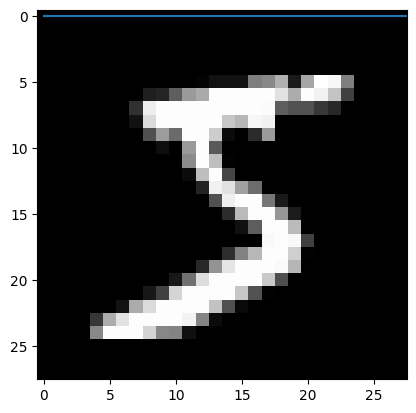

In [ ]:
print(label_train[0])
plt.plot(train_data[0,:])
plt.imshow(train_data[0,:].reshape(28,28), cmap = 'grey')
plt.show()

In [ ]:
# Convert MNIST image pixels into voltage pulse streams with duration 1 ms per pixel
dt = 0.001
Vmax = 0.9 # REPLACE with v_crit < DECREASE...
Vmin = 0.005
#bias = 2*Vmin
n_train = 200
train_T = n_train*784*dt
time_vec1 = np.arange(0,train_T,dt)
train_V = Vmax*train_data[:n_train,:].flatten()
for i in range(len(train_V)):
    train_V[i] = max(train_V[i],Vmin) # Outputs a voltage pulse of length (N x 784 x dt) seconds
                                      # And amplitude Vmax * pixel_intensity corresponding to each time step
print(train_V[200:300])

n_test = 50 #CHANGE < 200
test_T = n_test*784*dt
time_vec2 = np.arange(0,test_T,dt)
test_V = Vmax*test_data[:n_test,:].flatten()
for i in range(len(test_V)):
    test_V[i] = max(test_V[i],Vmin)


[0.005      0.005      0.005      0.17294118 0.84       0.89294118
 0.89294118 0.89294118 0.89294118 0.89294118 0.89294118 0.89294118
 0.89294118 0.88588235 0.32823529 0.28941176 0.28941176 0.19764706
 0.13764706 0.005      0.005      0.005      0.005      0.005
 0.005      0.005      0.005      0.005      0.005      0.005
 0.005      0.06352941 0.77294118 0.89294118 0.89294118 0.89294118
 0.89294118 0.89294118 0.69882353 0.64235294 0.87176471 0.85058824
 0.005      0.005      0.005      0.005      0.005      0.005
 0.005      0.005      0.005      0.005      0.005      0.005
 0.005      0.005      0.005      0.005      0.005      0.005
 0.28235294 0.55058824 0.37764706 0.89294118 0.89294118 0.72352941
 0.03882353 0.005      0.15176471 0.54352941 0.005      0.005
 0.005      0.005      0.005      0.005      0.005      0.005
 0.005      0.005      0.005      0.005      0.005      0.005
 0.005      0.005      0.005      0.005      0.005      0.04941176
 0.005      0.54352941 0.89294118 0

[5 0 4 1 9 2 1 3 1 4]


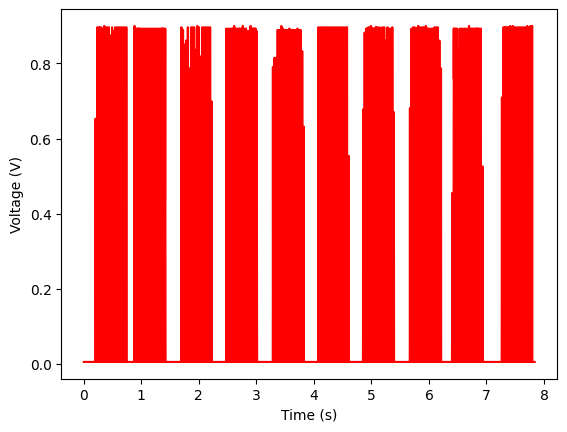

In [ ]:
print(label_train[0:10])

plt.plot(time_vec2[:7840],test_V[:7840], 'r')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
#plt.plot(time_vec1[:800],train_V[:800])
plt.show()

## V sweeping method - MNIST equivalent
Replicate DC v_crit method, testing for condutance-peaking at 'critical point' (first-order). ***Again, we can shorten n_train since network asymptotes after T = 40s (51 digits):***





In [ ]:
dt = 0.001
Vmin = 0.005
V_max = [0.5]
train_V_list = []
#bias = 2*Vmin
n_train = 200
train_T = n_train*784*dt

for volt in V_max:
  train_V = volt*train_data[:n_train,:].flatten()
  for i in range(len(train_V)):
    train_V[i] = max(train_V[i],Vmin)
  train_V_list.append(train_V)

Connectivity = connectivity__('100nw_261junctions.mat')
sim_list = []
final_conductances = []

i=0
while i < len(V_max):
  print(f"Running MNIST simulation for V_max = {V_max[i]}")
  sim = runSim(Connectivity,
                T = train_T, dt = dt, biasType = 'Custom',
                customSignal = train_V_list[i], lite_mode = True)
  sim_list.append(sim)
  i+=1

NameError: name 'train_data' is not defined

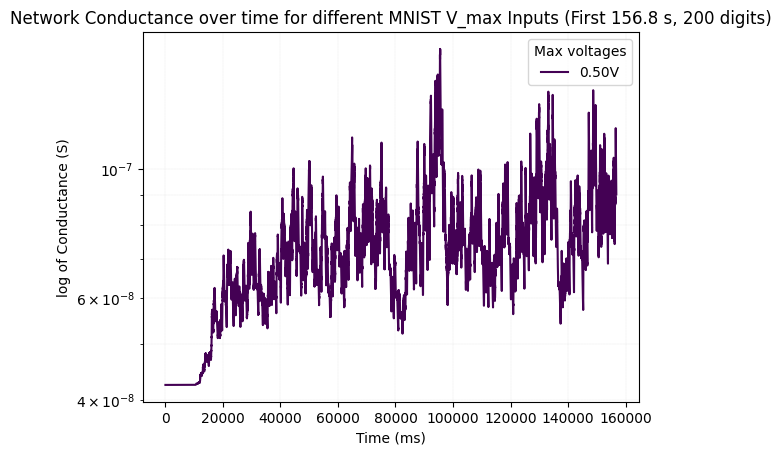

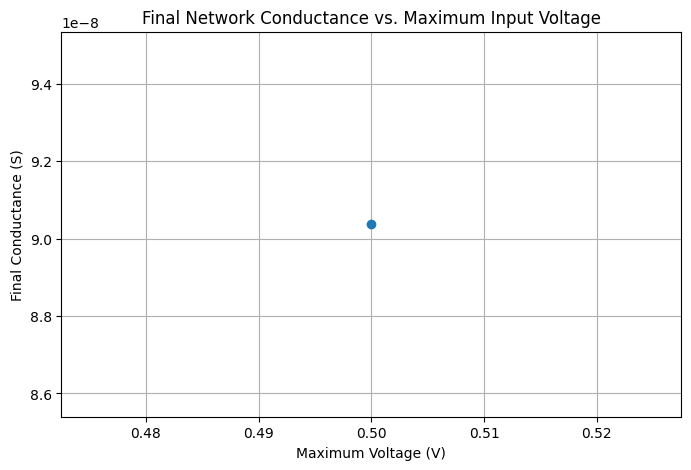

In [ ]:
# Use a colormap for different colors corresponding to MAX voltages
colors = plt.cm.viridis(np.linspace(0, 1, len(sim_list)))

for i, sim1 in enumerate(sim_list):
  plt.plot(sim1.conductance, color = colors[i], label = f'{V_max[i]:.2f}V')

plt.yscale('log')
plt.title(f'Network Conductance over time for different MNIST V_max Inputs (First {train_T} s, {n_train} digits)')
plt.xlabel('Time (ms)')
plt.ylabel('log of Conductance (S)')
plt.legend(title='Max voltages')
plt.grid(True, which="both", linestyle='--', linewidth=0.1)
plt.show()

final_conductances = []
for sim1 in sim_list:
  final_conductances.append(sim1.conductance[-1])

plt.figure(figsize=(8, 5))
plt.plot(V_max, final_conductances, marker='o', linestyle='-')
plt.xlabel('Maximum Voltage (V)')
plt.ylabel('Final Conductance (S)')
plt.title('Final Network Conductance vs. Maximum Input Voltage')
plt.grid(True)
plt.show()

## Network simulation and dynamic analysis USING V_CRIT
Stores testing and training data for the classification step

In [ ]:
Connectivity = connectivity__('100nw_261junctions.mat')
sim1 = runSim(Connectivity,
              T = train_T, dt = dt, biasType = 'Custom',
              customSignal = train_V, lite_mode = True) #CHANGE ?

|NWN Sim:   0%|          | 0/156800 [00:00<?, ?it/s]

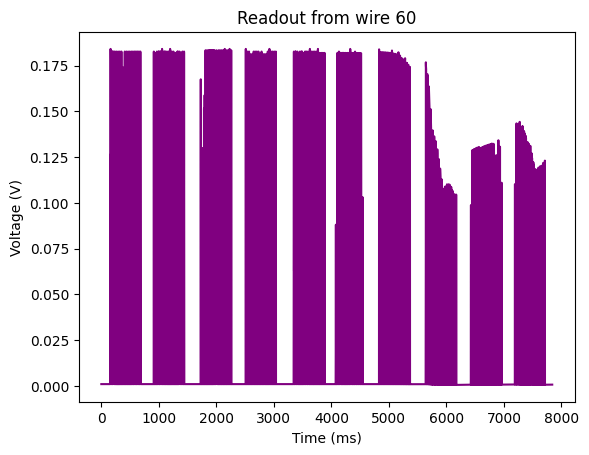

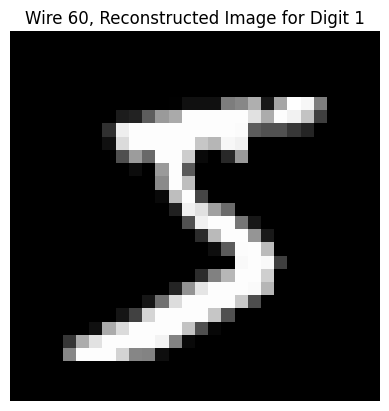

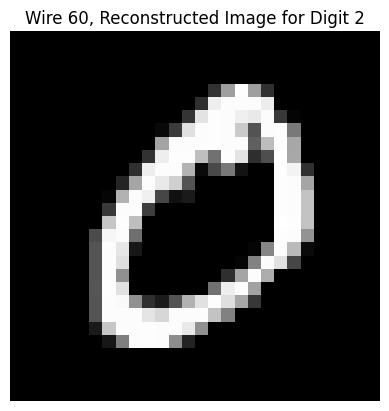

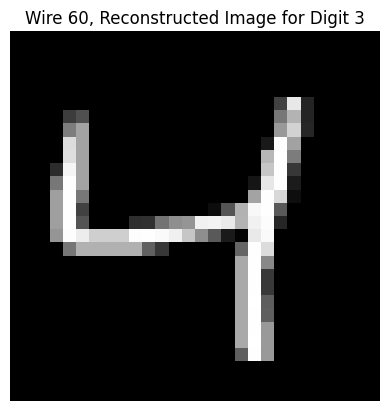

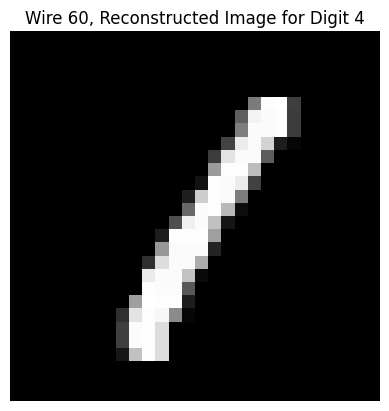

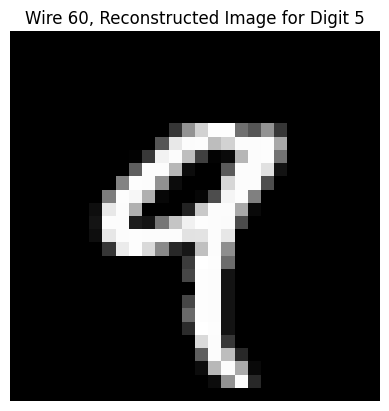

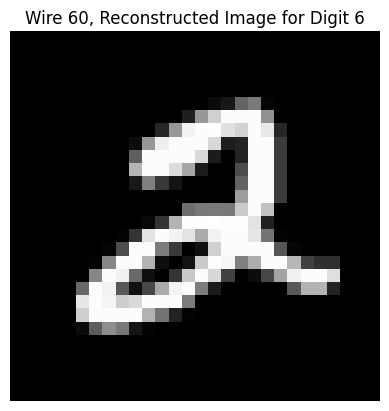

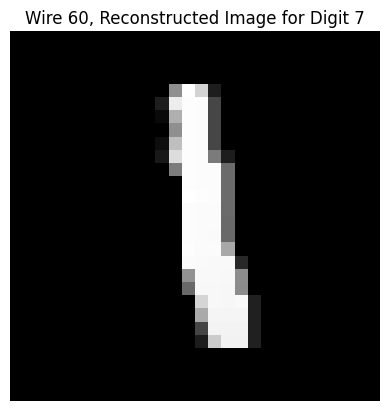

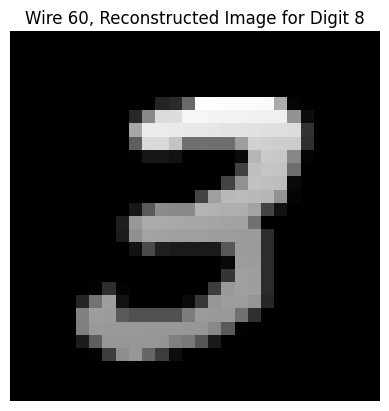

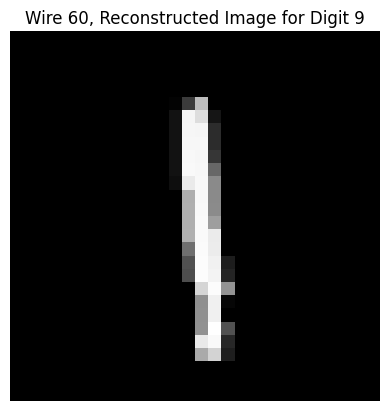

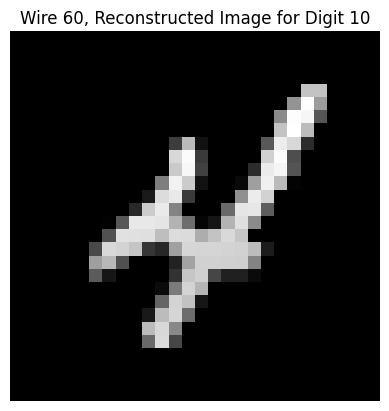

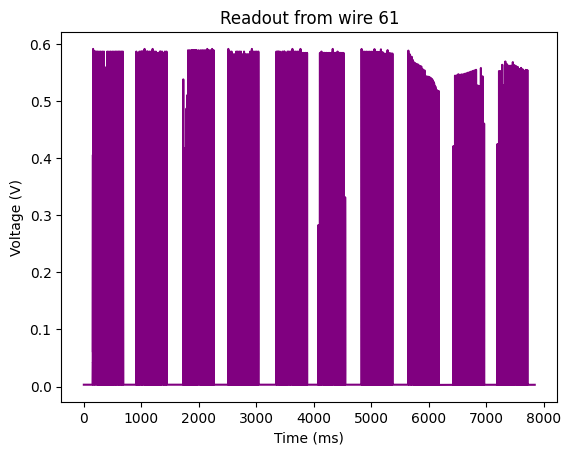

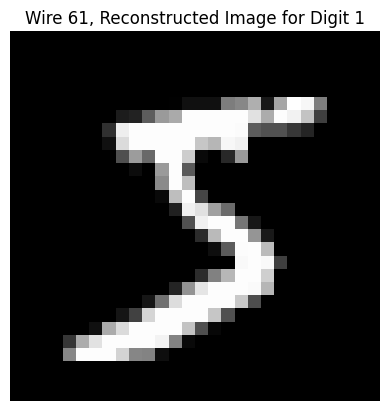

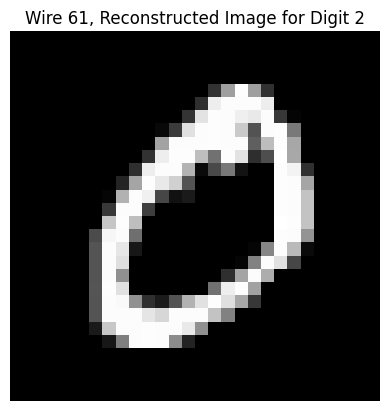

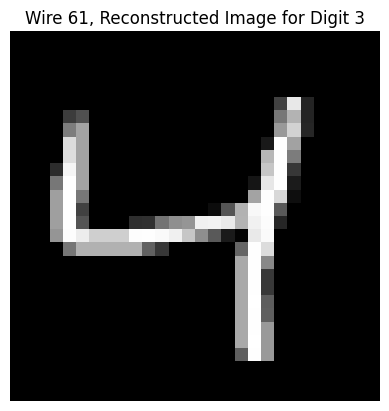

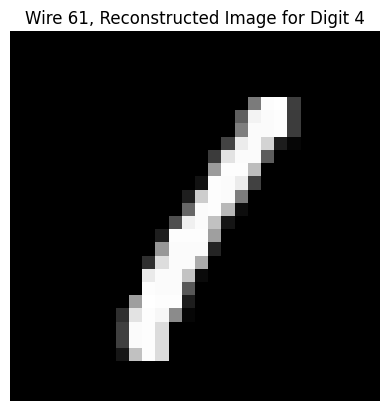

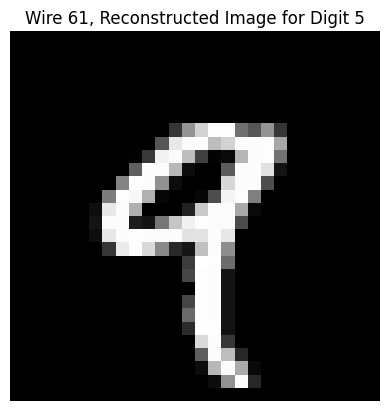

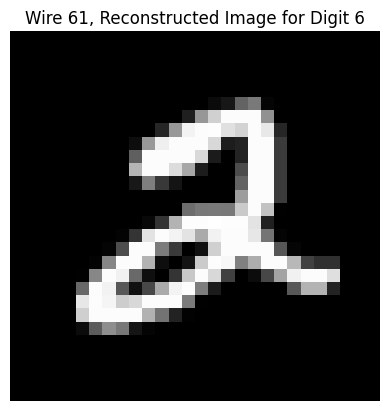

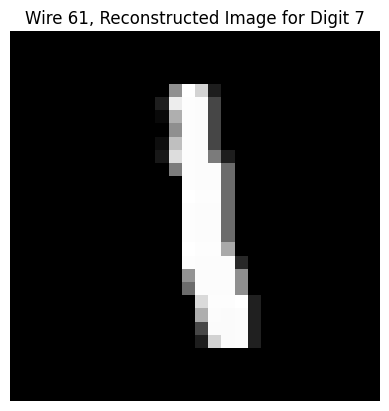

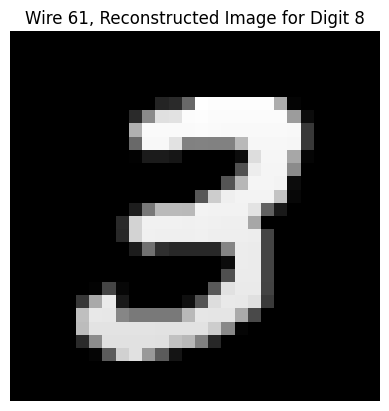

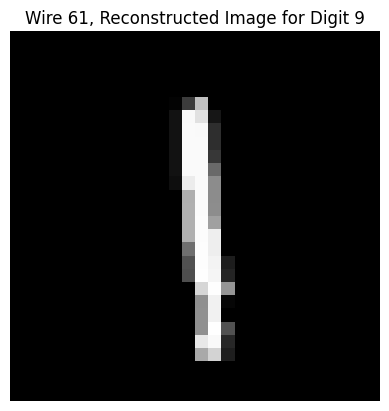

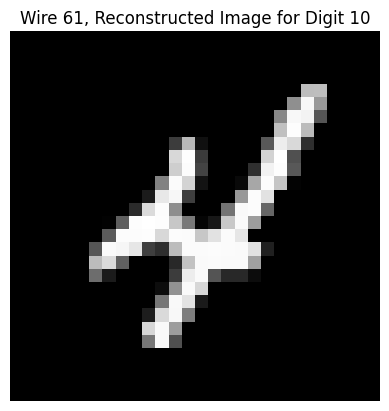

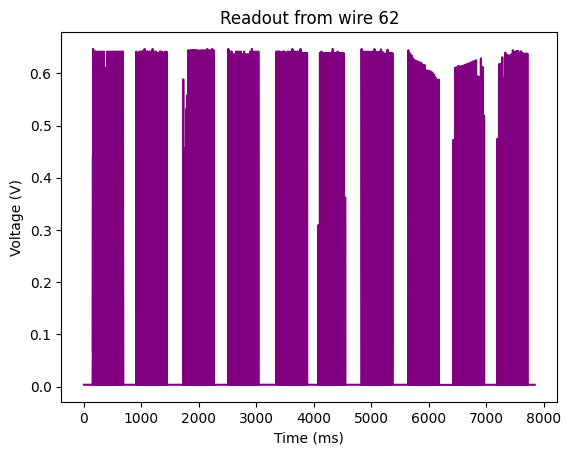

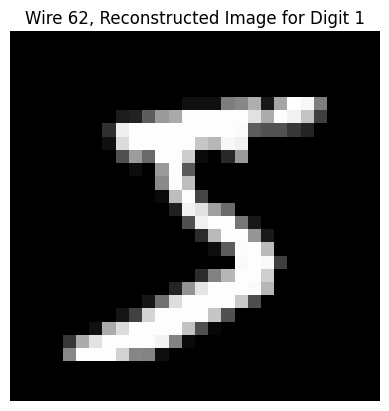

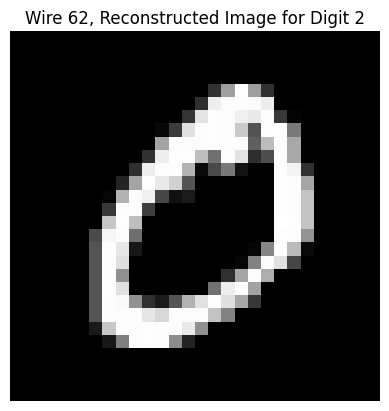

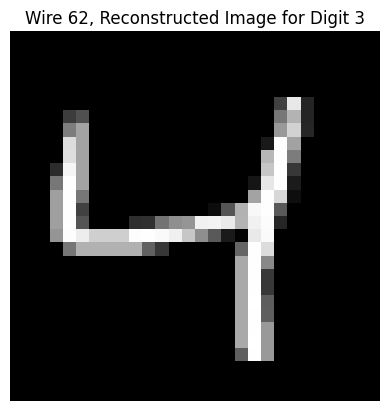

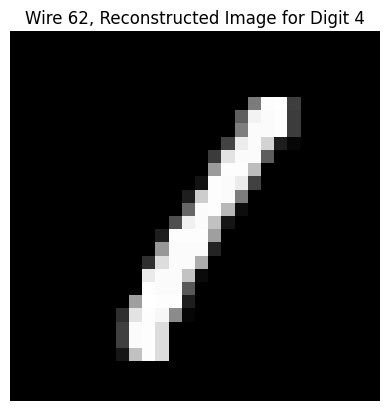

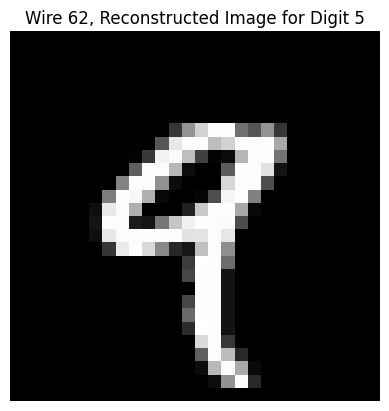

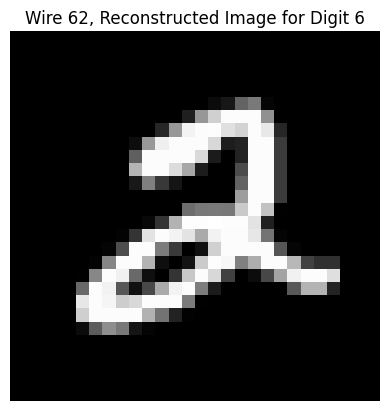

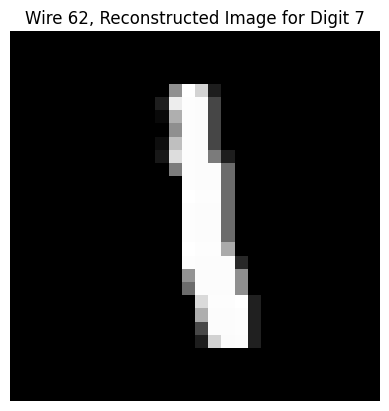

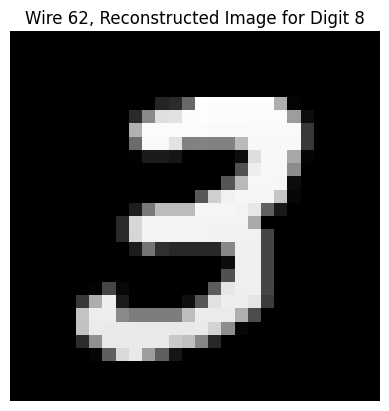

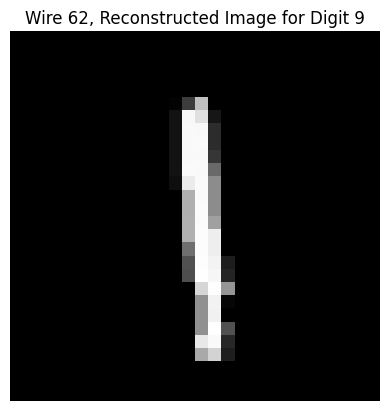

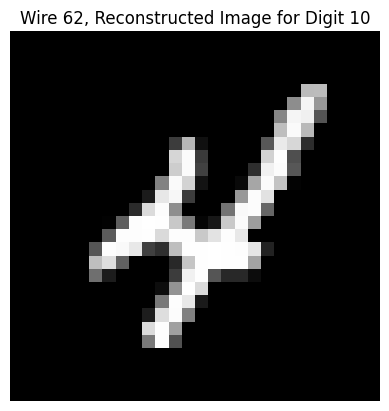

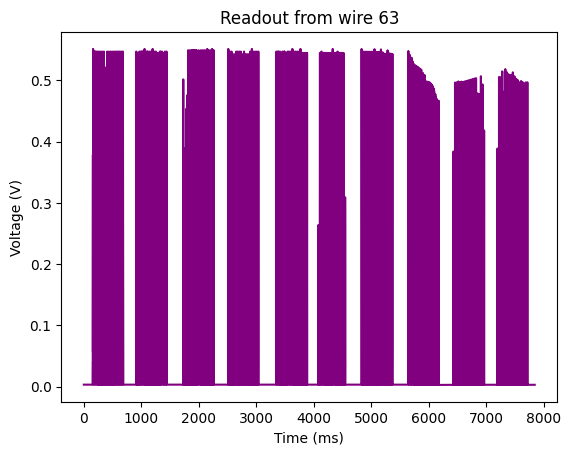

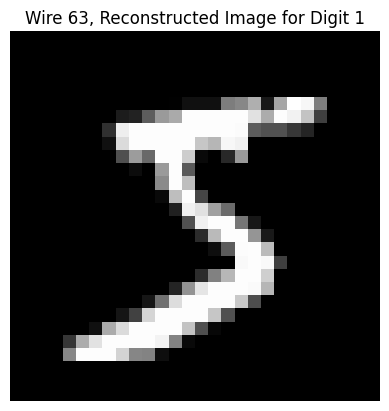

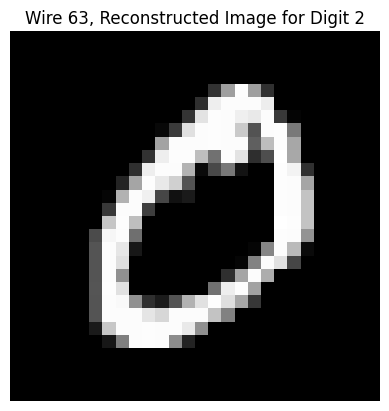

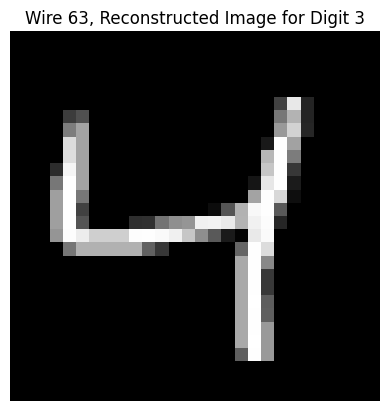

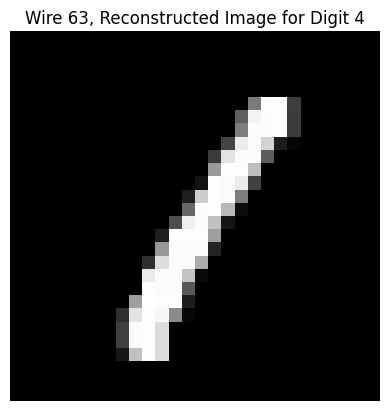

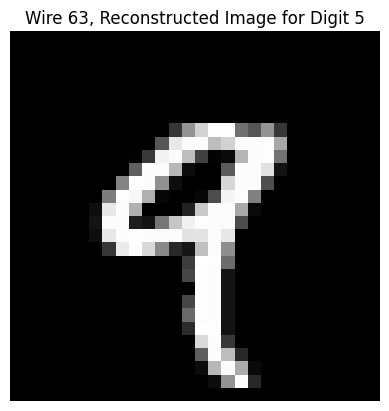

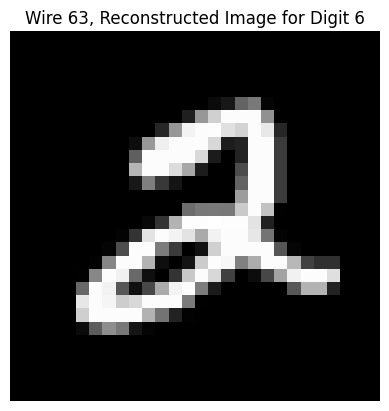

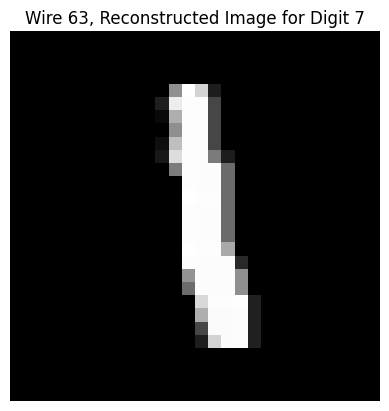

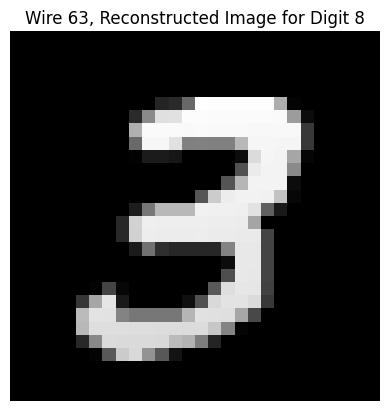

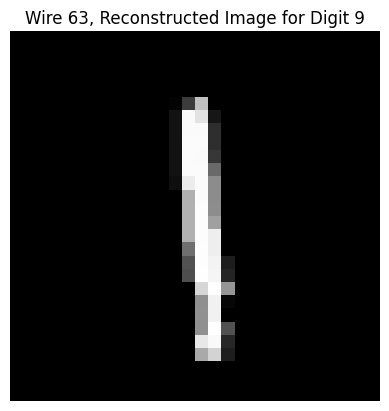

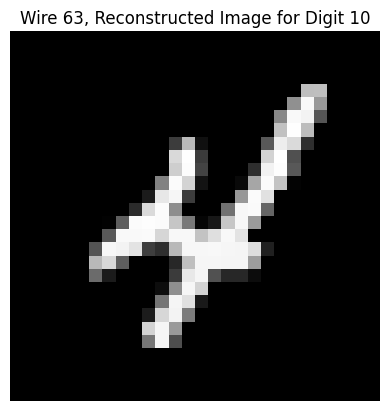

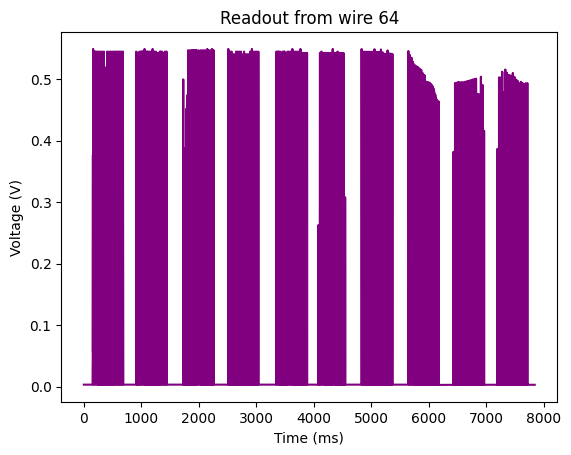

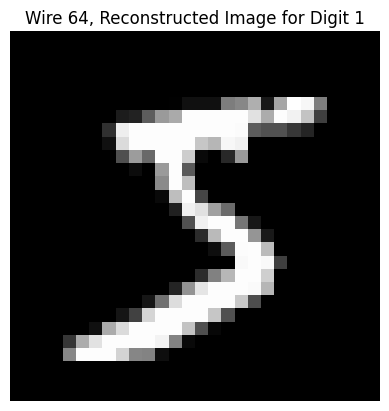

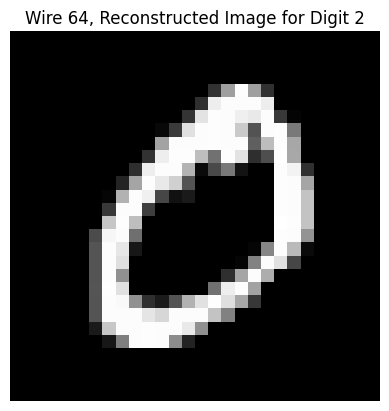

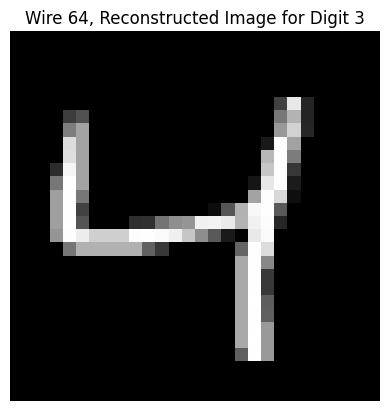

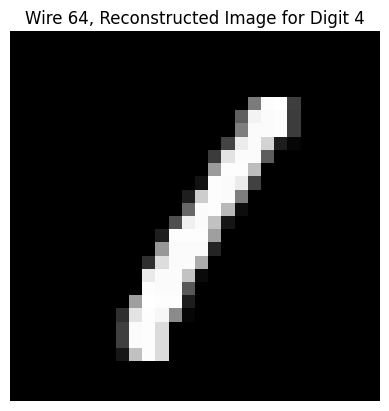

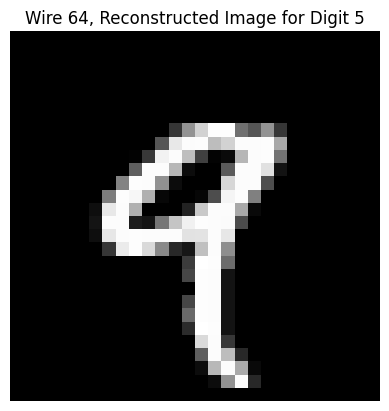

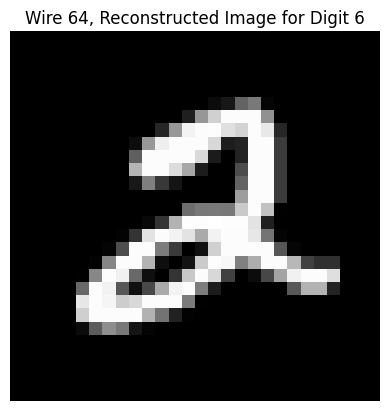

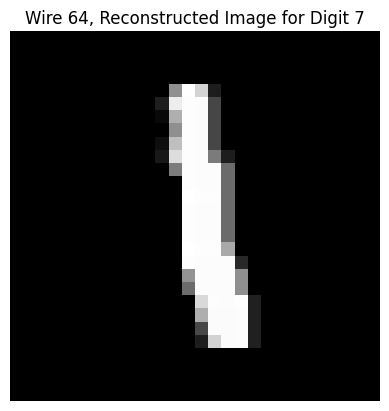

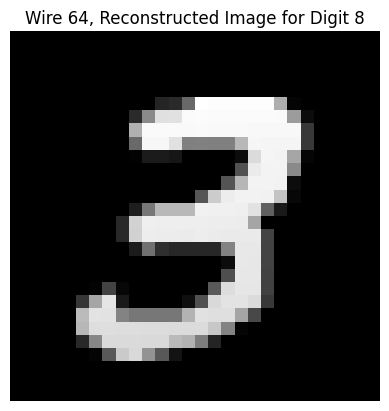

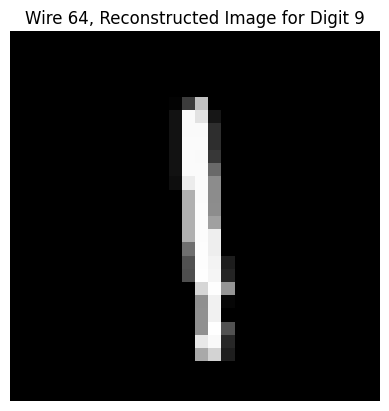

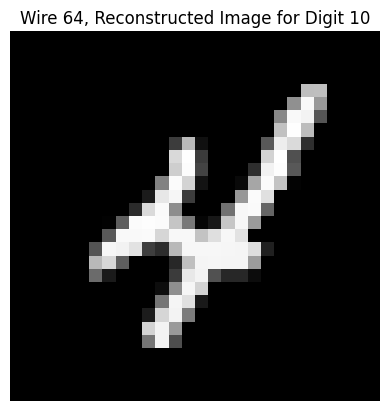

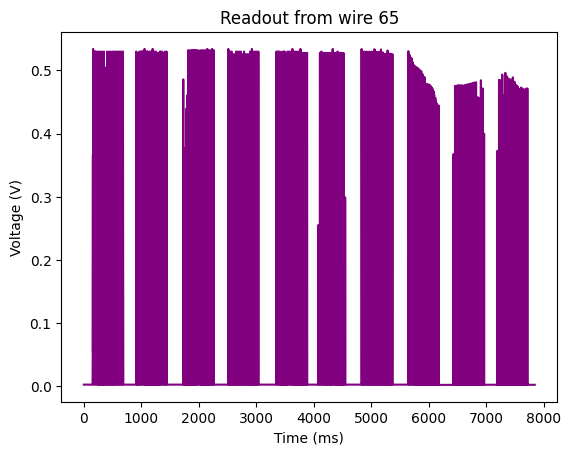

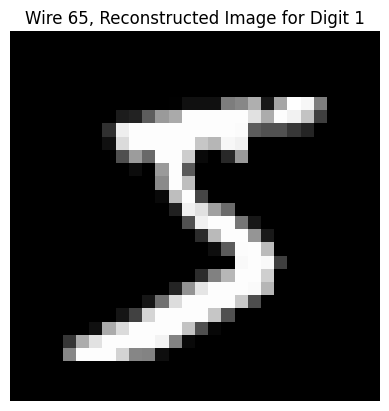

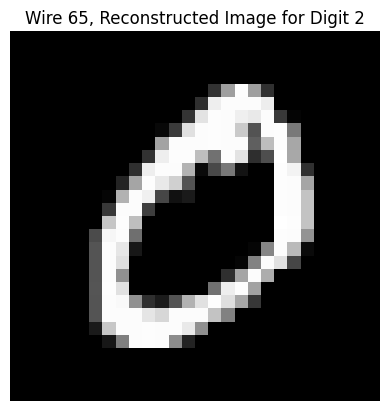

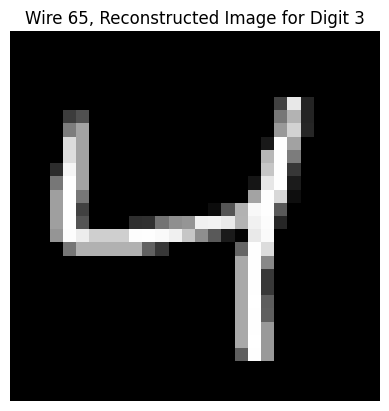

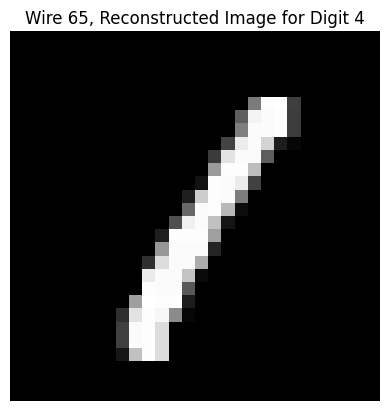

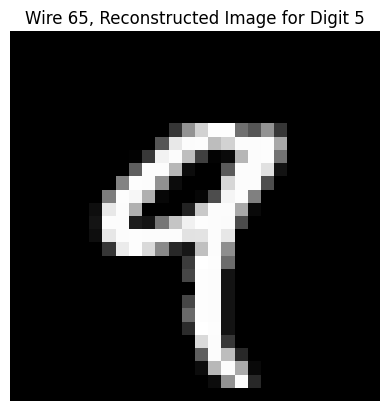

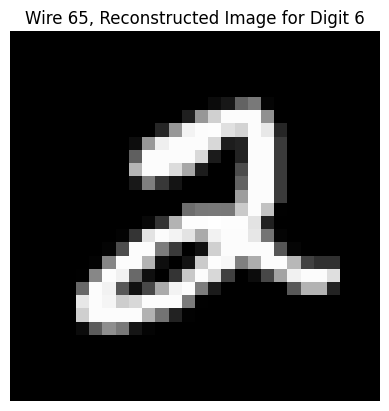

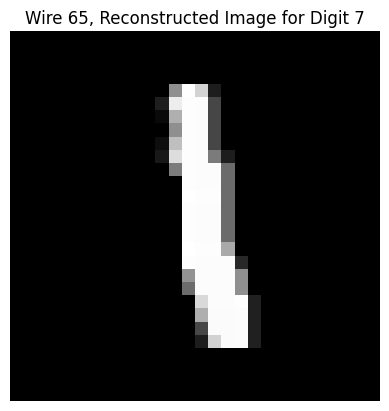

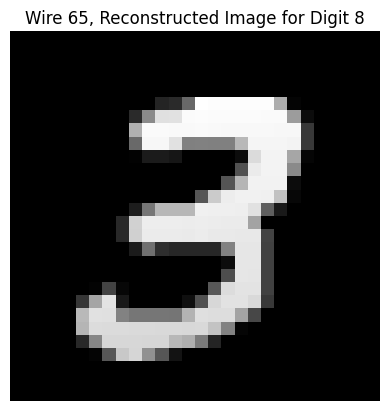

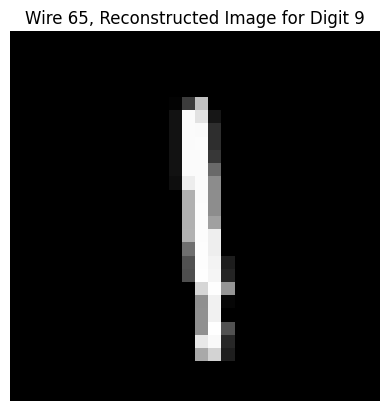

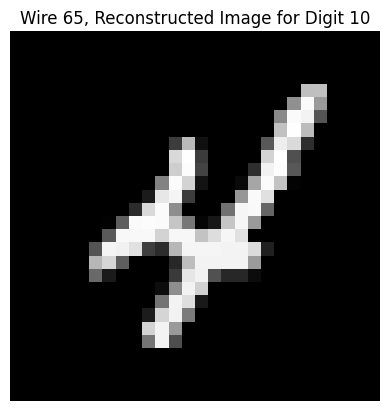

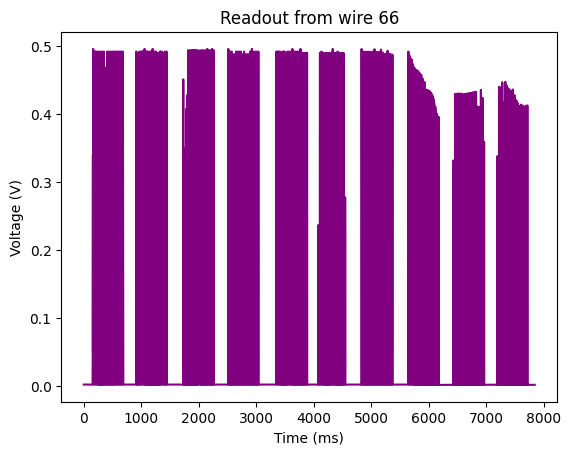

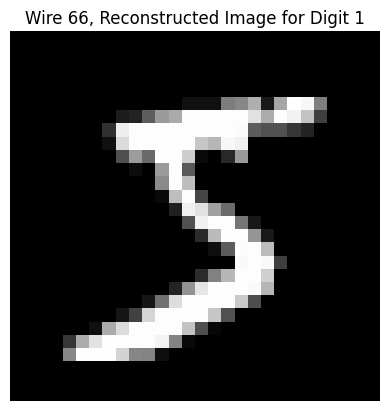

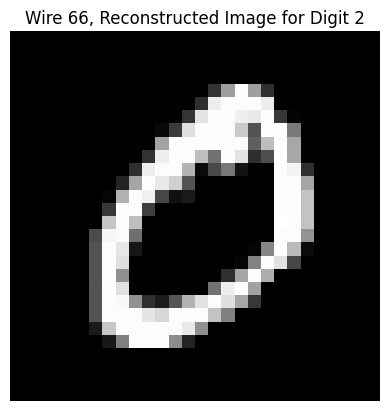

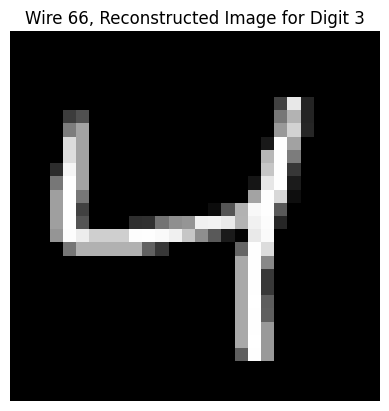

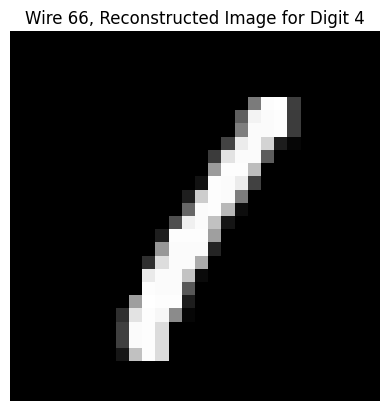

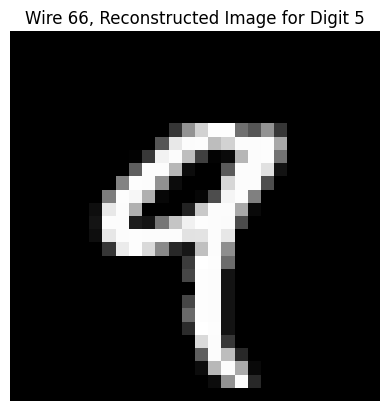

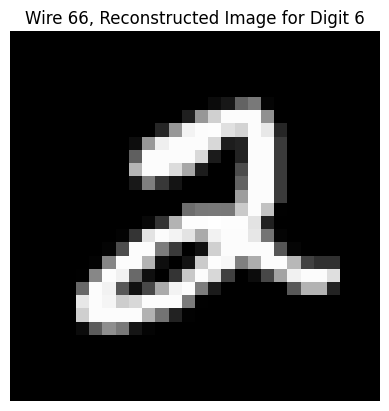

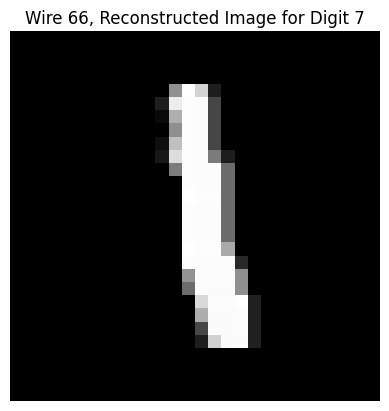

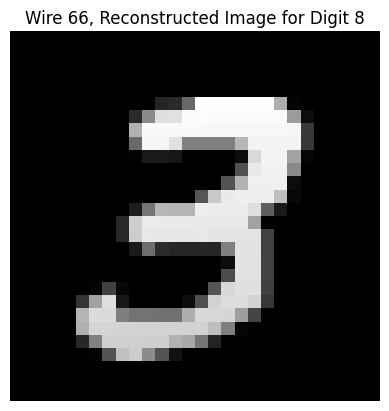

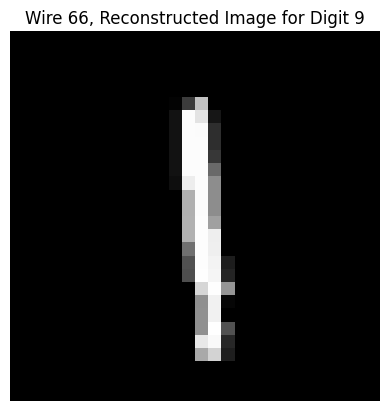

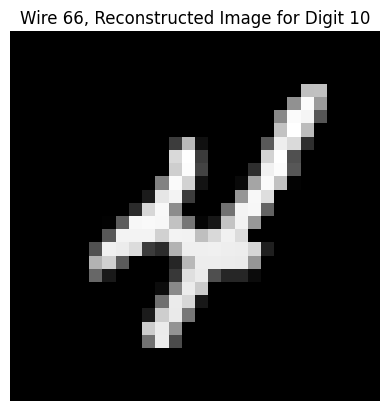

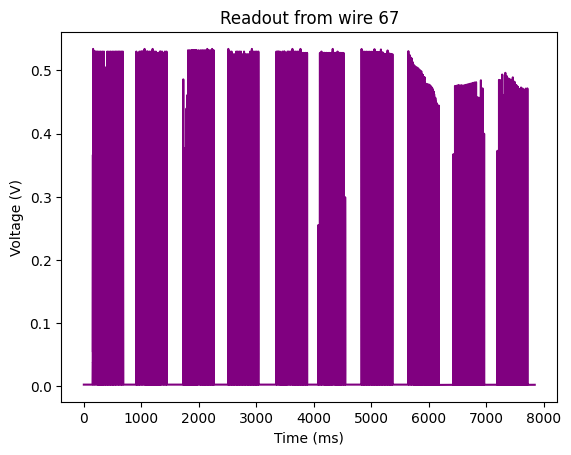

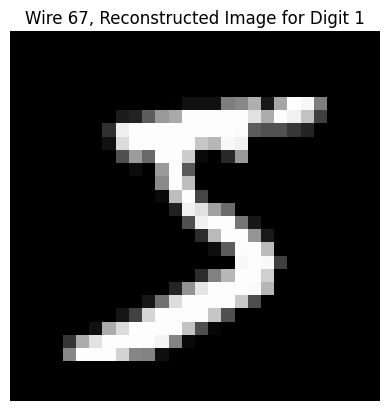

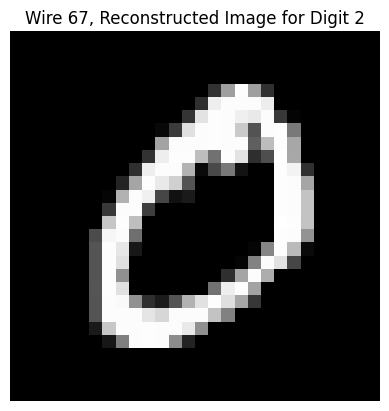

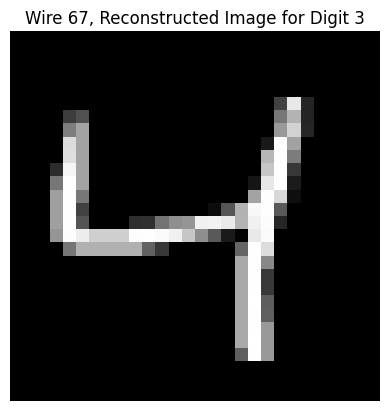

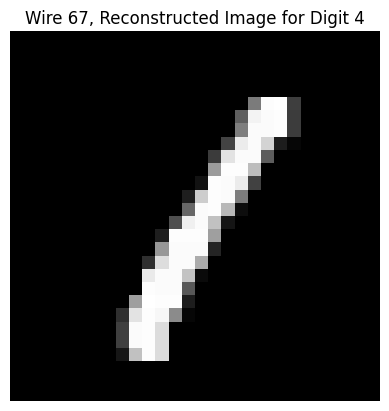

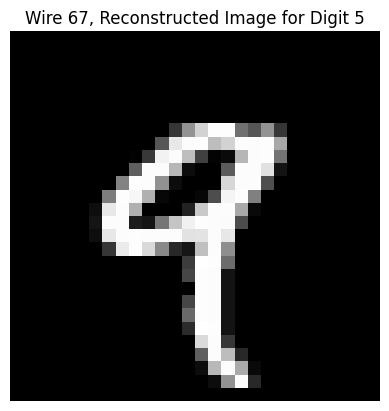

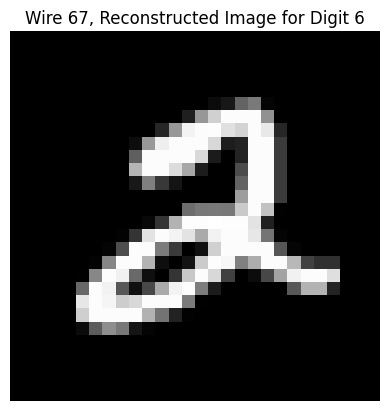

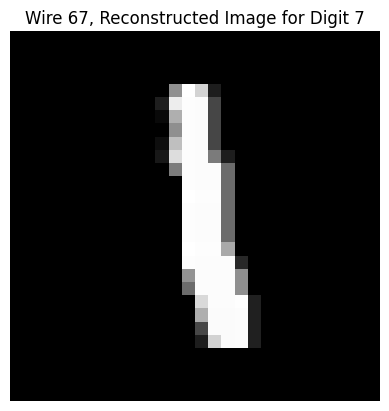

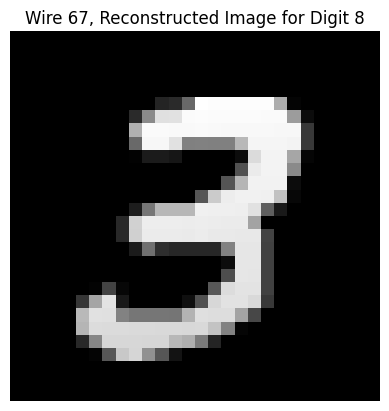

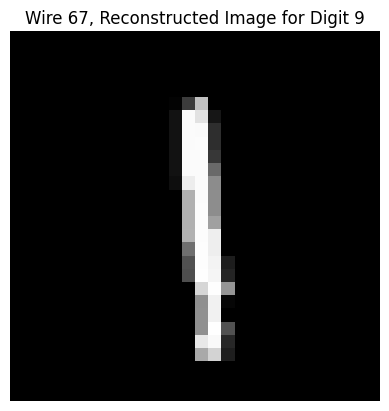

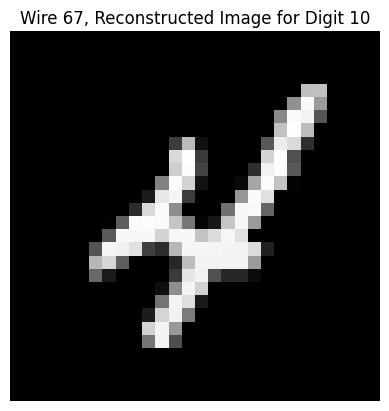

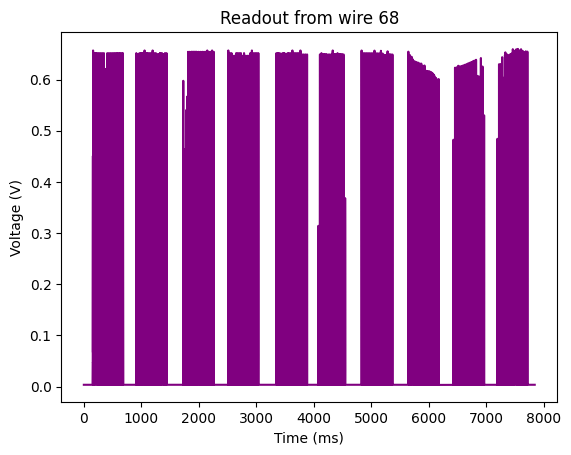

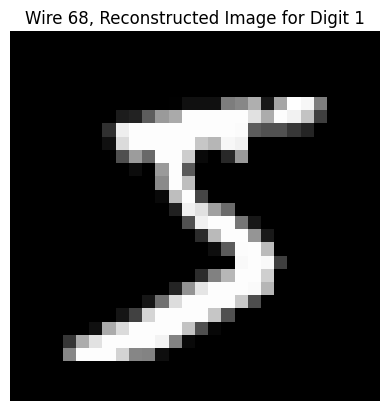

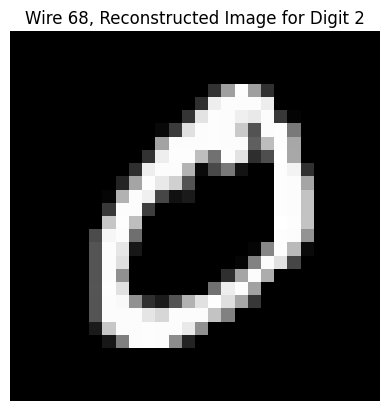

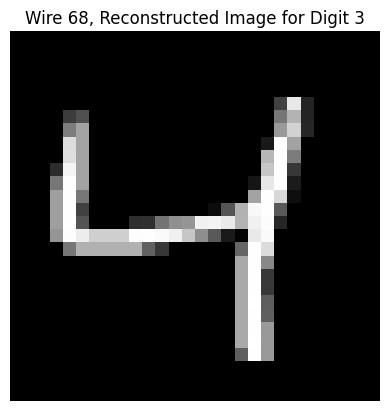

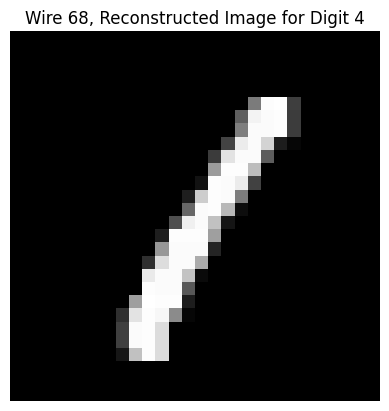

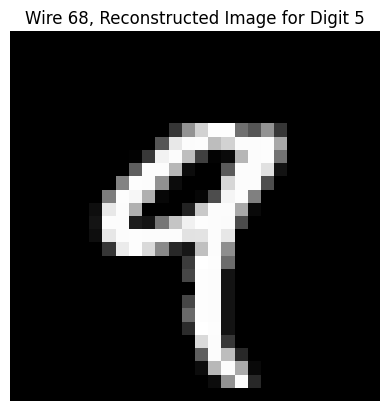

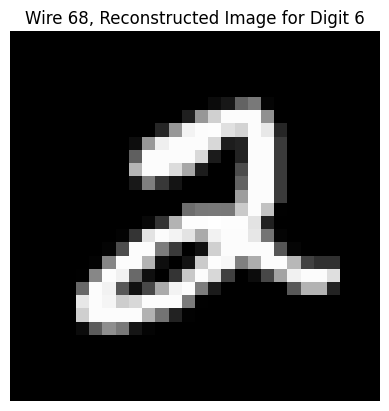

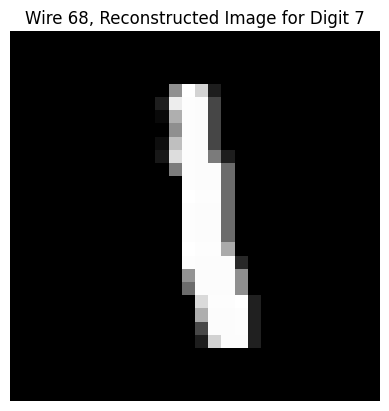

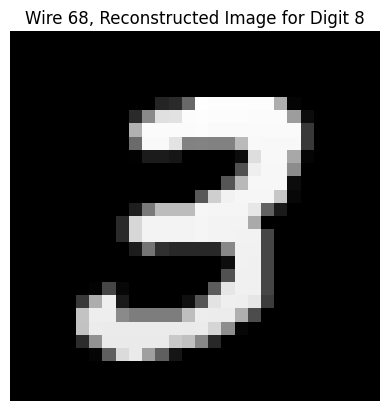

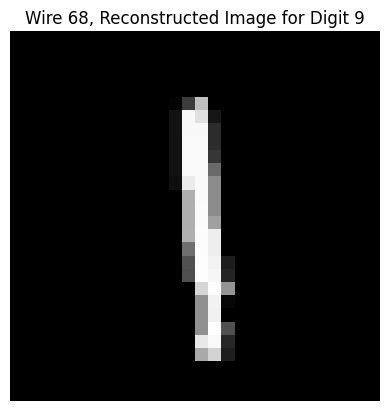

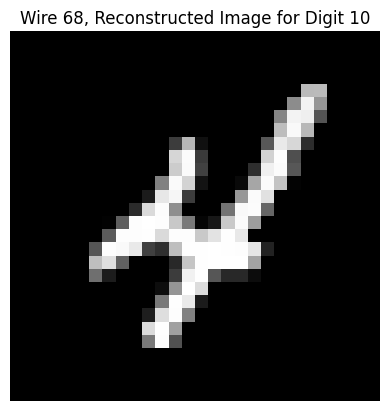

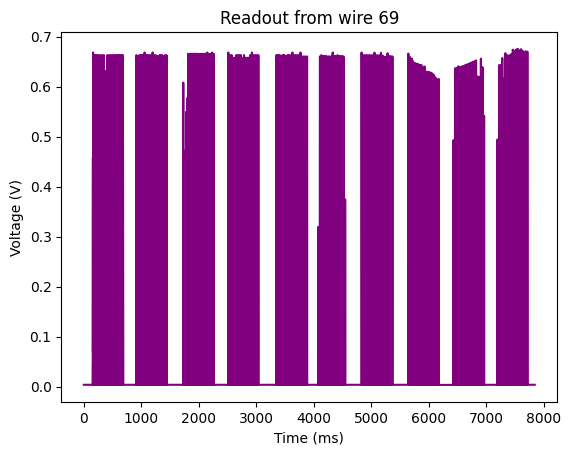

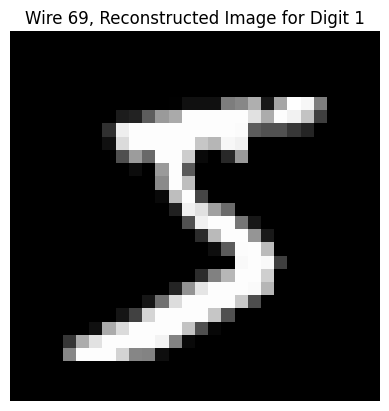

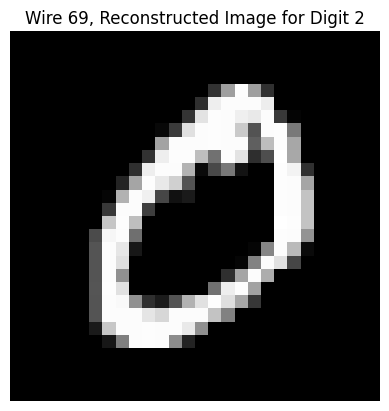

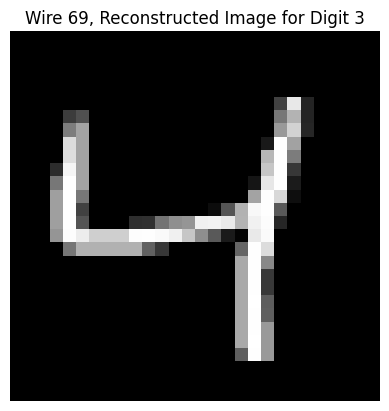

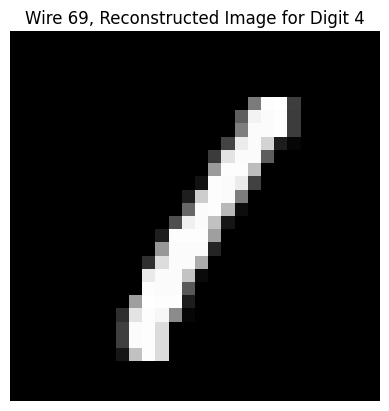

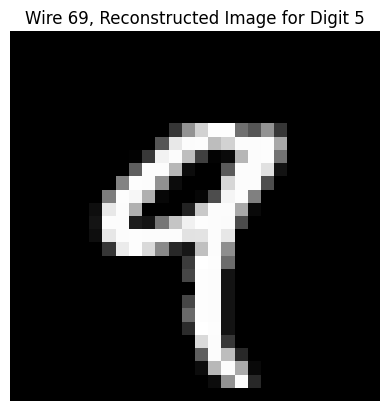

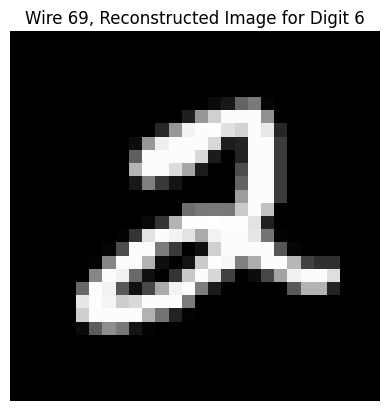

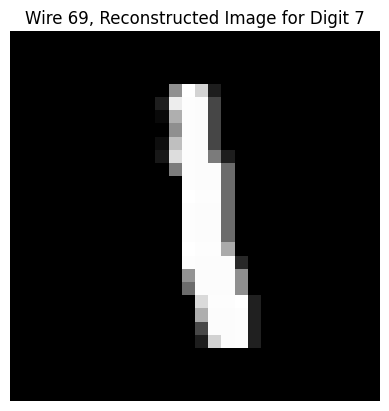

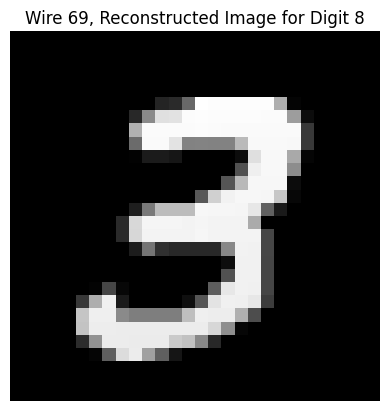

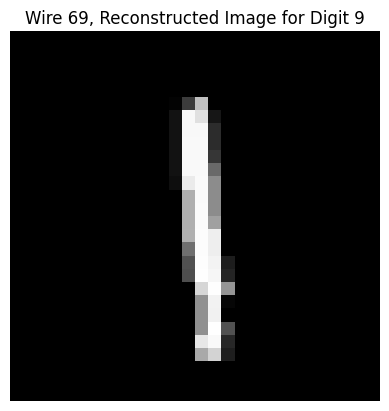

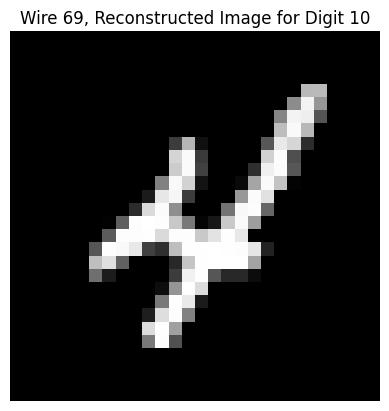

In [ ]:
# readouts_train = sim1.wireVoltage[:,60:70] # Removed unused line


'''To run multiple plots:'''
n_digits_plot = 10
i = 60
while i < 70:
  readout_data_wire = sim1.wireVoltage[:,i] # Get data for the current wire
  '''Plot readouts time series'''
  plt.plot(readout_data_wire[0:784*n_digits_plot], 'purple')
  plt.title('Readout from wire ' + str(i))
  plt.xlabel('Time (ms)')
  plt.ylabel('Voltage (V)')
  plt.show() # Display the time series plot for the current wire

  '''Image re-shaping and plotting for the first n_digits_plot digits'''
  j=0
  while j < n_digits_plot:
    # Extract data for the current digit (784 time steps = 784 ms)
    digit_data_1d = readout_data_wire[j*784:(j+1)*784]
    digit_image_2d = digit_data_1d.reshape(28,28)
    plt.imshow(digit_image_2d, cmap='gray')
    plt.title(f'Wire {i}, Reconstructed Image for Digit {j+1}')
    plt.axis('off') # Turn off axis numbers and ticks
    plt.show() # Display the reconstructed image for the current digit

    j+=1 # Move to the next digit
  i+=1 # Move to the next wire

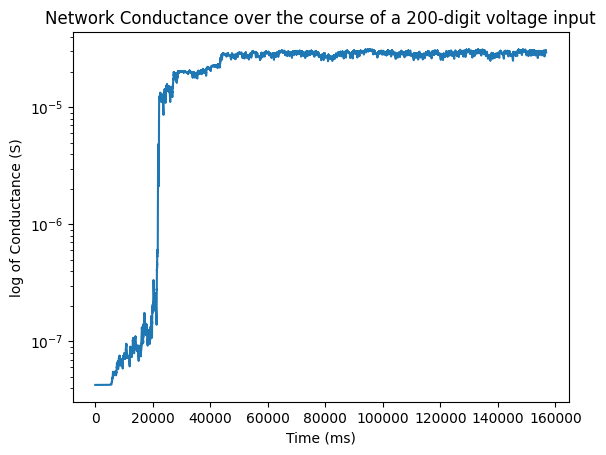

In [ ]:
plt.yscale("log")
plt.plot(sim1.conductance[:])
plt.title(f'Network Conductance over the course of a {n_train}-digit voltage input')
plt.xlabel('Time (ms)')
plt.ylabel('log of Conductance (S)')
plt.show()

Try DIFFERENT number of readouts - change readouts when change the network (drain/input)

In [ ]:
# help(draw_graph) # Keep this line if you want to see the help again
# Assuming sim1.junctionVoltage contains the voltage data for junctions
# You might need to adjust the indexing based on the structure of your data
draw_graph(sim1, time=7000, edge_weight=sim1.junctionVoltage, edge_mode = 'voltage', edge_colorbar=True, title='Network Junction Voltage at t = 7s')


AttributeError: 'network__' object has no attribute 'junctionVoltage'

In [ ]:
# repeat simulation for test data
sim2 = runSim(Connectivity,
              T = test_T, dt = dt, biasType = 'Custom',
              customSignal = test_V, lite_mode = False)

|NWN Sim:   0%|          | 0/39200 [00:00<?, ?it/s]

In [ ]:
readouts_test = sim2.wireVoltage[:,60:70]

## Classification
Use training readouts to train a linear classifier, using NN_classify, and testing readouts to test the classifier.
$$ WX = Y$$
where $W [10 \times K]$ is the classifier, $X [K \times N]$ are the readouts (features), and $Y [10 \times N]$ are the MNIST labels, with $K = 784M$ features per sample, $M =$ no. readouts, and $N =$ no. samples.


In [ ]:
# reshape matrices - X is transposed to KxN in NN_classify, so need to reshape to NxK here:
K = 784*readouts_train.shape[1]
X1 = readouts_train.reshape([n_train,K])
K = 784*readouts_test.shape[1]
X2 = readouts_test.reshape([n_test,K])
X = np.concatenate((X1, X2), axis=0)

# note: Y is reshaped in NN_classify
Y1 = label_train[:n_train]
Y2 = label_test[:n_test]
Y = np.concatenate((Y1, Y2))
train_ratio = len(X1)/len(X)
print(Y1.shape, Y2.shape, Y.shape)
train_ratio = len(X1[1])/len(X2[1])
print(train_ratio)

(200,) (50,) (250,)
1.0


In [ ]:
from edamame.analysis.classify import NN_classify
from sklearn.metrics import classification_report, confusion_matrix # Import these here to ensure they are available for printing shapes
import numpy as np # Ensure numpy is imported

# Run classification
classification_accuracy, raw_predictions, raw_labels = NN_classify(X, Y, train_ratio=0.8, epochs=10)

# Explicitly flatten and convert predictions and labels to integer arrays
predictions = raw_predictions.flatten().astype(int)
labels = raw_labels.flatten().astype(int)

# Add print statements to check shapes before classification_report
print("Shape of predictions:", predictions.shape)
print("Shape of labels:", labels.shape)






  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 2 cost:  15.921735654109167
Epoch 4 cost:  10.014596691340303
Epoch 6 cost:  7.38265838268813
Epoch 8 cost:  4.0352736777748115
Epoch 10 cost:  2.9073553561511916
Epoch 12 cost:  2.254133314068567
Epoch 14 cost:  1.5994397611443958
Epoch 16 cost:  1.1860382118824193
Epoch 18 cost:  0.9859367417016912
Epoch 20 cost:  0.8615963425627582
0.64
[[5 0 0 0 0 0 0 0 0 0]
 [0 6 0 0 0 1 0 0 1 3]
 [0 0 1 0 1 0 1 2 0 0]
 [0 0 0 5 0 0 0 0 0 0]
 [0 0 0 0 6 1 1 0 0 2]
 [0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 4 1 0 0]
 [0 1 0 0 0 0 0 2 0 0]
 [0 0 0 1 0 0 0 1 2 0]
 [0 0 0 0 0 0 0 0 0 1]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       0.86      0.55      0.67        11
           2       1.00      0.20      0.33         5
           3       0.71      1.00      0.83         5
           4       0.86      0.60      0.71        10
           5       0.00      0.00      0.00         1
           6       0.67      0.80      0.7

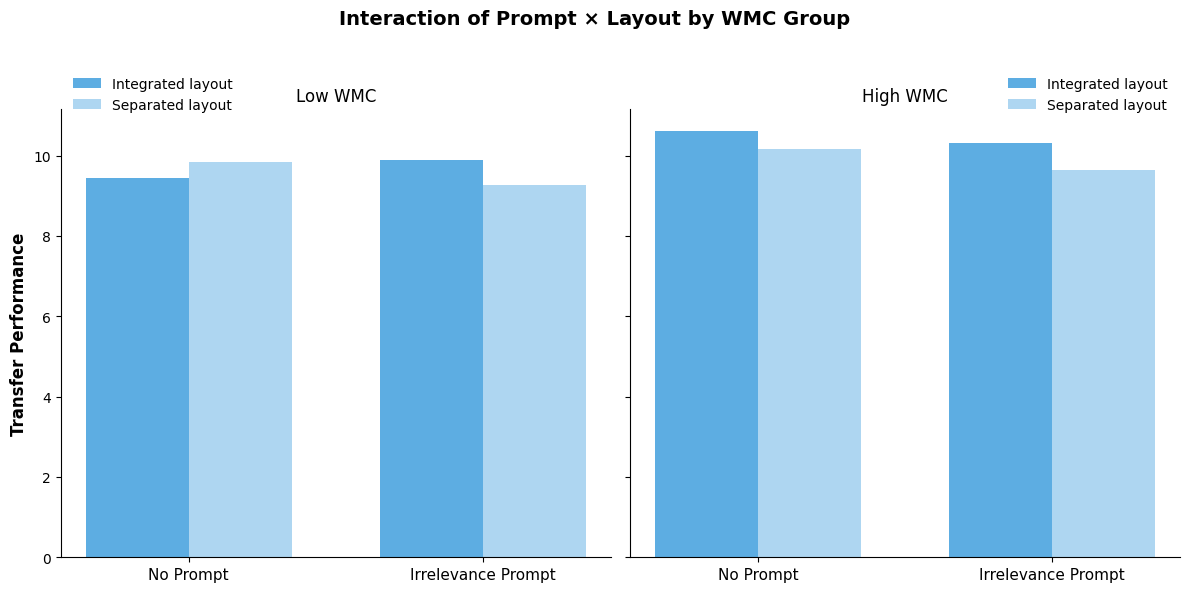